# Twitter Image Probing Analysis
Load saved probing outputs, visualize image-level heatmaps, and inspect aggregate statistics for Twitter images.

In [1]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")
sns.set_style("whitegrid")

In [2]:
def load_outputs(ridge_prefix, model_name="qwen3-vl-8b-instruct"):
    scores_path = Path(f"results/{model_name}/twitter_images_patch_scores_{ridge_prefix}.pt")
    stats_path = Path(f"results/{model_name}/twitter_images_patch_stats_{ridge_prefix}.csv")

    if not scores_path.exists():
        raise FileNotFoundError(f"Missing scores file: {scores_path}")
    if not stats_path.exists():
        raise FileNotFoundError(f"Missing stats file: {stats_path}")

    payload = torch.load(scores_path, map_location="cpu")
    df_stats = pd.read_csv(stats_path)

    print(f"Loaded scores: {scores_path}")
    print(f"Loaded stats : {stats_path}")
    print(f"Num images   : {len(payload['image_paths'])}")
    print("Metadata:")
    display(pd.Series(payload.get("metadata", {}), name="value"))
    return payload, df_stats


In [3]:
def get_image_scores_for_index(payload, idx):
    offsets = payload["offsets"].numpy()
    scores = payload["scores"].numpy()
    start, end = int(offsets[idx]), int(offsets[idx + 1])
    return scores[start:end]


def overlay_heatmap_on_image(img_pil, heatmap_hw, alpha=0.45, cmap="jet", vmin=None, vmax=None):
    img = np.asarray(img_pil.convert("RGB")).astype(np.float32) / 255.0
    H, W = img.shape[:2]

    hm = heatmap_hw.astype(np.float32)
    if vmin is None:
        vmin = float(np.nanmin(hm))
    if vmax is None:
        vmax = float(np.nanmax(hm))
    denom = (vmax - vmin) if (vmax - vmin) > 1e-8 else 1.0
    hm01 = np.clip((hm - vmin) / denom, 0.0, 1.0)

    hm_up = np.array(
        Image.fromarray((hm01 * 255).astype(np.uint8)).resize((W, H), resample=Image.Resampling.NEAREST)
    ) / 255.0

    cm = plt.get_cmap(cmap)
    hm_rgb = cm(hm_up)[..., :3]
    out = (1 - alpha) * img + alpha * hm_rgb
    return np.clip(out, 0.0, 1.0)


def show_heatmap_examples(payload, n=6, seed=7):
    n_total = len(payload["image_paths"])
    if n_total == 0:
        print("No images in payload.")
        return

    rng = np.random.default_rng(seed)
    choices = rng.choice(n_total, size=min(n, n_total), replace=False)

    for idx in choices:
        image_path = payload["image_paths"][idx]
        grid_h, grid_w = payload["grid_hw"][idx].tolist()
        flat_scores = get_image_scores_for_index(payload, idx)

        if len(flat_scores) != grid_h * grid_w:
            print(f"Skipping {image_path}: score length mismatch")
            continue

        heat = flat_scores.reshape(grid_h, grid_w)
        img = Image.open(image_path).convert("RGB")
        over = overlay_heatmap_on_image(img, heat, alpha=0.45, cmap="jet", vmin=-1, vmax=1)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(img)
        axes[0].set_title(f"Original\n{Path(image_path).name}")
        axes[0].axis("off")

        axes[1].imshow(over)
        axes[1].set_title(
            f"Overlay (mean={float(np.mean(flat_scores)):.3f}, std={float(np.std(flat_scores)):.3f})"
        )
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()


In [4]:
def analyze_party_comparison(df_stats, meta_path=Path("data/twitter_images_metadata.csv")):
    if not meta_path.exists():
        raise FileNotFoundError(f"Missing metadata file: {meta_path}")

    df_meta = pd.read_csv(meta_path)
    required_meta_cols = {"party", "url", "filename"}
    missing_meta_cols = required_meta_cols - set(df_meta.columns)
    if missing_meta_cols:
        raise ValueError(f"Missing required metadata columns: {sorted(missing_meta_cols)}")

    df_cmp = df_stats.copy()
    df_cmp["image_name"] = df_cmp["image_name"].astype(str)
    df_cmp["image_basename"] = df_cmp["image_path"].astype(str).apply(lambda p: Path(p).name)

    df_meta = df_meta.copy()
    df_meta["url_name"] = df_meta["url"].astype(str).apply(lambda u: Path(u).name)
    df_meta["filename"] = df_meta["filename"].astype(str)
    df_meta["party"] = df_meta["party"].astype(str).str.strip()

    # Use whichever key recovers more party labels.
    meta_by_url = df_meta[["url_name", "party"]].drop_duplicates("url_name")
    meta_by_file = df_meta[["filename", "party"]].drop_duplicates("filename")

    df_url_join = df_cmp.merge(meta_by_url, how="left", left_on="image_name", right_on="url_name")
    url_match_count = int(df_url_join["party"].notna().sum())

    df_file_join = df_cmp.merge(meta_by_file, how="left", left_on="image_basename", right_on="filename")
    file_match_count = int(df_file_join["party"].notna().sum())

    if url_match_count >= file_match_count:
        df_party = df_url_join.copy()
        join_mode = "url basename (image_name <-> url)"
    else:
        df_party = df_file_join.copy()
        join_mode = "local filename (image_path basename <-> filename)"

    print(f"Join mode: {join_mode}")
    print(f"Matched party labels: {int(df_party['party'].notna().sum())}/{len(df_party)}")

    df_party = df_party[df_party["party"].isin(["Democrat", "Republican"])].copy()
    if df_party.empty:
        raise RuntimeError("No Democrat/Republican rows available after merge. Check metadata alignment.")

    party_summary = (
        df_party.groupby("party", as_index=False)
        .agg(
            n_images=("mean", "size"),
            mean_of_mean=("mean", "mean"),
            median_of_mean=("mean", "median"),
            std_of_mean=("mean", "std"),
            mean_patch_std=("std", "mean"),
            mean_num_patches=("num_patches", "mean"),
        )
        .sort_values("party")
        .reset_index(drop=True)
    )

    display(party_summary)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    sns.boxplot(data=df_party, x="party", y="mean", palette="Set2", ax=axes[0])
    axes[0].axhline(0.0, linestyle="--", linewidth=1, color="gray")
    axes[0].set_title("Patch-Mean Score by Party")
    axes[0].set_xlabel("Party")
    axes[0].set_ylabel("Per-image mean probe score")

    sns.violinplot(data=df_party, x="party", y="mean", inner="quartile", palette="Set2", ax=axes[1])
    axes[1].axhline(0.0, linestyle="--", linewidth=1, color="gray")
    axes[1].set_title("Distribution Shape by Party")
    axes[1].set_xlabel("Party")
    axes[1].set_ylabel("Per-image mean probe score")

    sns.barplot(data=party_summary, x="party", y="n_images", palette="Set2", ax=axes[2])
    axes[2].set_title("Image Count by Party")
    axes[2].set_xlabel("Party")
    axes[2].set_ylabel("Number of images")

    plt.tight_layout()
    plt.show()

    q = (
        df_party.groupby("party")["mean"]
        .quantile([0.05, 0.25, 0.5, 0.75, 0.95])
        .unstack()
        .rename(columns={0.05: "q05", 0.25: "q25", 0.5: "q50", 0.75: "q75", 0.95: "q95"})
        .reset_index()
        .sort_values("party")
    )
    display(q)

    return df_party


In [5]:
from scipy import stats as scipy_stats


def analyze_statistical_inference(df_party):
    dem = df_party.loc[df_party["party"] == "Democrat", "mean"].dropna().to_numpy()
    rep = df_party.loc[df_party["party"] == "Republican", "mean"].dropna().to_numpy()

    if len(dem) < 2 or len(rep) < 2:
        raise RuntimeError("Not enough samples per party for inference tests.")

    # Welch t-test: compares means without equal-variance assumption.
    t_stat, t_p = scipy_stats.ttest_ind(dem, rep, equal_var=False)

    # Mann-Whitney U: non-parametric test for distribution shift.
    u_stat, u_p = scipy_stats.mannwhitneyu(dem, rep, alternative="two-sided")

    # Effect sizes.
    mean_diff = float(rep.mean() - dem.mean())
    pooled_sd = float(np.sqrt(((len(rep) - 1) * rep.var(ddof=1) + (len(dem) - 1) * dem.var(ddof=1)) / (len(rep) + len(dem) - 2)))
    cohens_d = mean_diff / pooled_sd if pooled_sd > 0 else np.nan

    # Cliff's delta (ordinal effect size): P(rep > dem) - P(rep < dem).
    pairwise = rep[:, None] - dem[None, :]
    cliffs_delta = float((np.sum(pairwise > 0) - np.sum(pairwise < 0)) / pairwise.size)

    # Bootstrap CI for mean difference (rep - dem).
    rng = np.random.default_rng(42)
    n_boot = 5000
    boot_diffs = np.empty(n_boot, dtype=np.float64)
    for i in range(n_boot):
        rep_s = rng.choice(rep, size=len(rep), replace=True)
        dem_s = rng.choice(dem, size=len(dem), replace=True)
        boot_diffs[i] = rep_s.mean() - dem_s.mean()
    ci_low, ci_high = np.quantile(boot_diffs, [0.025, 0.975])

    results = pd.DataFrame(
        [
            {"metric": "n_democrat", "value": len(dem)},
            {"metric": "n_republican", "value": len(rep)},
            {"metric": "mean_diff_rep_minus_dem", "value": mean_diff},
            {"metric": "mean_diff_bootstrap_ci_low", "value": float(ci_low)},
            {"metric": "mean_diff_bootstrap_ci_high", "value": float(ci_high)},
            {"metric": "welch_t_stat", "value": float(t_stat)},
            {"metric": "welch_t_pvalue", "value": float(t_p)},
            {"metric": "mannwhitney_u_stat", "value": float(u_stat)},
            {"metric": "mannwhitney_u_pvalue", "value": float(u_p)},
            {"metric": "cohens_d", "value": float(cohens_d)},
            {"metric": "cliffs_delta", "value": float(cliffs_delta)},
        ]
    )
    display(results)

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    sns.histplot(boot_diffs, bins=50, kde=True, color="tab:purple", ax=ax)
    ax.axvline(0.0, linestyle="--", color="black", linewidth=1)
    ax.axvline(ci_low, linestyle=":", color="tab:red", linewidth=2, label=f"2.5% = {ci_low:.4f}")
    ax.axvline(ci_high, linestyle=":", color="tab:red", linewidth=2, label=f"97.5% = {ci_high:.4f}")
    ax.axvline(mean_diff, linestyle="-", color="tab:green", linewidth=2, label=f"Observed diff = {mean_diff:.4f}")
    ax.set_title("Bootstrap Distribution: Mean Difference (Republican - Democrat)")
    ax.set_xlabel("Mean difference")
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return results


In [6]:
def analyze_dw_nominate(
    df_stats,
    meta_path=Path("data/twitter_images_metadata.csv"),
    leg_path=Path("data/legislators_116_119_with_twitter.csv"),
    dw_path=Path("data/HS116_members.csv"),
):
    for p in [meta_path, leg_path, dw_path]:
        if not p.exists():
            raise FileNotFoundError(f"Missing required file: {p}")

    df_meta = pd.read_csv(meta_path)
    df_leg = pd.read_csv(leg_path)
    df_dw = pd.read_csv(dw_path)

    df_img = df_stats.copy()
    df_img["image_name"] = df_img["image_name"].astype(str)

    df_meta = df_meta.copy()
    df_meta["url_name"] = df_meta["url"].astype(str).apply(lambda u: Path(u).name)
    df_meta["screen_key"] = df_meta["screen_name"].astype(str).str.strip().str.lower().str.lstrip("@")

    df_leg = df_leg.copy()
    df_leg["twitter_key"] = df_leg["twitter"].astype(str).str.strip().str.lower().str.lstrip("@")

    df_dw = df_dw.copy()
    df_dw = df_dw[df_dw["congress"] == 116].copy()
    df_dw["bioguide_id"] = df_dw["bioguide_id"].astype(str)
    dw_cols = ["bioguide_id", "nominate_dim1", "nominate_dim2", "party_code", "bioname"]
    df_dw = df_dw[dw_cols].dropna(subset=["bioguide_id", "nominate_dim1"]).drop_duplicates("bioguide_id")

    df_join = (
        df_img.merge(df_meta[["url_name", "screen_key", "party"]], how="left", left_on="image_name", right_on="url_name")
        .merge(df_leg[["twitter_key", "bioguide", "name", "party"]], how="left", left_on="screen_key", right_on="twitter_key", suffixes=("_meta", "_leg"))
        .merge(df_dw, how="left", left_on="bioguide", right_on="bioguide_id")
    )
    df_join["party_final"] = df_join["party_meta"].fillna(df_join["party_leg"]).fillna("Unknown")

    matched = int(df_join["nominate_dim1"].notna().sum())
    print(f"Rows with DW-NOMINATE match: {matched}/{len(df_join)}")

    df_corr = df_join.dropna(subset=["nominate_dim1", "mean"]).copy()
    if len(df_corr) < 10:
        raise RuntimeError("Too few rows after joining nominate_dim1 with image means.")

    pearson_r, pearson_p = scipy_stats.pearsonr(df_corr["nominate_dim1"], df_corr["mean"])
    spearman_rho, spearman_p = scipy_stats.spearmanr(df_corr["nominate_dim1"], df_corr["mean"])

    corr_table = pd.DataFrame(
        [
            {"metric": "n_rows", "value": len(df_corr)},
            {"metric": "n_unique_members", "value": df_corr["bioguide"].nunique()},
            {"metric": "pearson_r", "value": float(pearson_r)},
            {"metric": "pearson_p", "value": float(pearson_p)},
            {"metric": "spearman_rho", "value": float(spearman_rho)},
            {"metric": "spearman_p", "value": float(spearman_p)},
        ]
    )
    display(corr_table)

    member_agg = (
        df_corr.groupby(["bioguide", "name", "party_final", "nominate_dim1"], as_index=False)
        .agg(
            n_images=("mean", "size"),
            mean_image_score=("mean", "mean"),
            std_image_score=("mean", "std"),
        )
        .sort_values("n_images", ascending=False)
        .reset_index(drop=True)
    )

    pearson_m_r, pearson_m_p = scipy_stats.pearsonr(member_agg["nominate_dim1"], member_agg["mean_image_score"])
    spearman_m_rho, spearman_m_p = scipy_stats.spearmanr(member_agg["nominate_dim1"], member_agg["mean_image_score"])

    member_corr_table = pd.DataFrame(
        [
            {"metric": "member_level_n", "value": len(member_agg)},
            {"metric": "member_level_pearson_r", "value": float(pearson_m_r)},
            {"metric": "member_level_pearson_p", "value": float(pearson_m_p)},
            {"metric": "member_level_spearman_rho", "value": float(spearman_m_rho)},
            {"metric": "member_level_spearman_p", "value": float(spearman_m_p)},
        ]
    )
    display(member_corr_table)

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    sns.regplot(
        data=df_corr, x="nominate_dim1", y="mean",
        scatter_kws={"alpha": 0.25, "s": 22},
        line_kws={"color": "tab:red", "linewidth": 2},
        ax=ax,
    )
    ax.axvline(0.0, linestyle="--", color="gray", linewidth=1)
    ax.axhline(0.0, linestyle="--", color="gray", linewidth=1)
    ax.set_title("Image-level: DW-NOMINATE vs Image Mean")
    ax.set_xlabel("DW-NOMINATE dim1")
    ax.set_ylabel("Per-image mean probe score")
    ax.text(
        0.03, 0.97,
        f"Pearson r={pearson_r:.3f} (p={pearson_p:.2e})\nSpearman rho={spearman_rho:.3f} (p={spearman_p:.2e})",
        transform=ax.transAxes, ha="left", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
    )
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    sns.scatterplot(
        data=member_agg, x="nominate_dim1", y="mean_image_score",
        hue="party_final", size="n_images", sizes=(20, 250), alpha=0.8, ax=ax,
    )
    sns.regplot(
        data=member_agg, x="nominate_dim1", y="mean_image_score",
        scatter=False, line_kws={"color": "black", "linewidth": 2}, ax=ax,
    )
    ax.axvline(0.0, linestyle="--", color="gray", linewidth=1)
    ax.axhline(0.0, linestyle="--", color="gray", linewidth=1)
    ax.set_title("Member-level Means: DW-NOMINATE vs Image Mean")
    ax.set_xlabel("DW-NOMINATE dim1")
    ax.set_ylabel("Member average image mean score")
    ax.text(
        0.03, 0.97,
        f"Pearson r={pearson_m_r:.3f} (p={pearson_m_p:.2e})\nSpearman rho={spearman_m_rho:.3f} (p={spearman_m_p:.2e})",
        transform=ax.transAxes, ha="left", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
    )
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()
    plt.show()

    display(member_agg.head(20))
    return df_corr, member_agg



  Ridge prefix: politician

Loaded scores: results/qwen3-vl-8b-instruct/twitter_images_patch_scores_politician.pt
Loaded stats : results/qwen3-vl-8b-instruct/twitter_images_patch_stats_politician.csv
Num images   : 1367
Metadata:


model_path         /home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct
image_dir                                       data/twitter_images
ridge_prefix                                             politician
top_k                                                            16
prompt            Analyze this image. What political perspective...
max_width                                                       800
image_pad_id                                                 151655
skipped_images                                                    0
Name: value, dtype: object

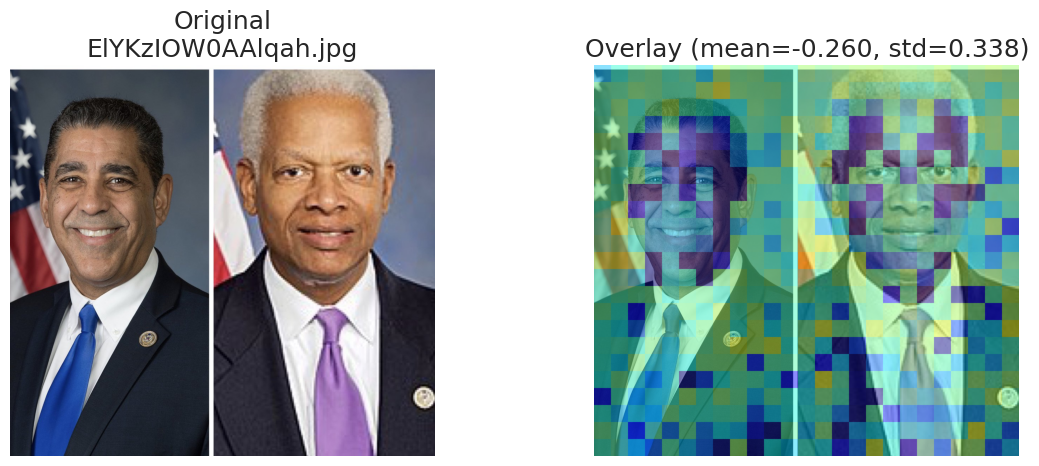

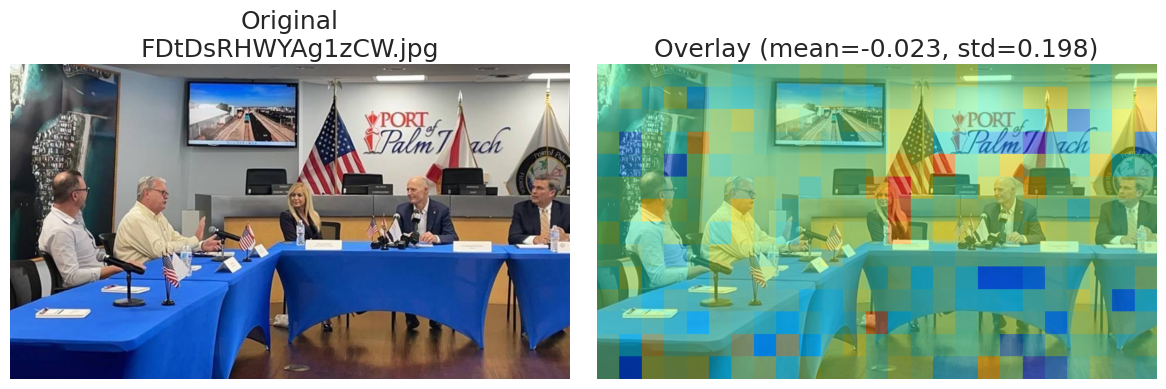

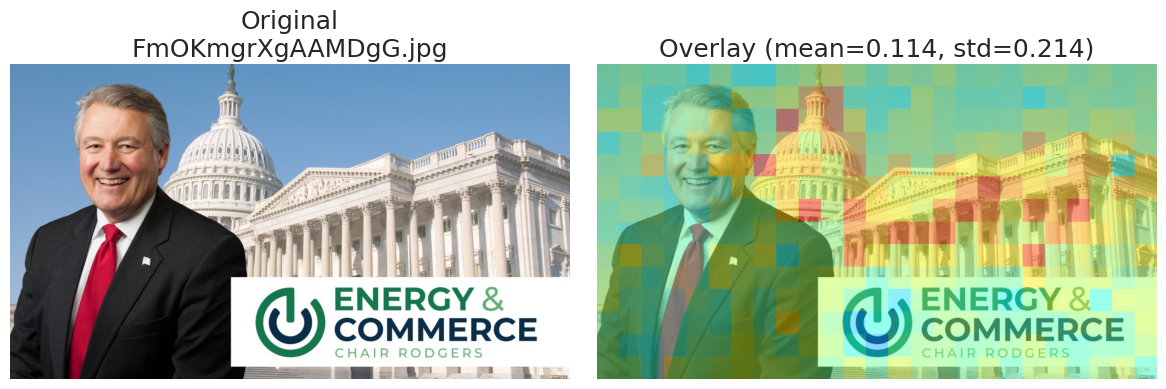

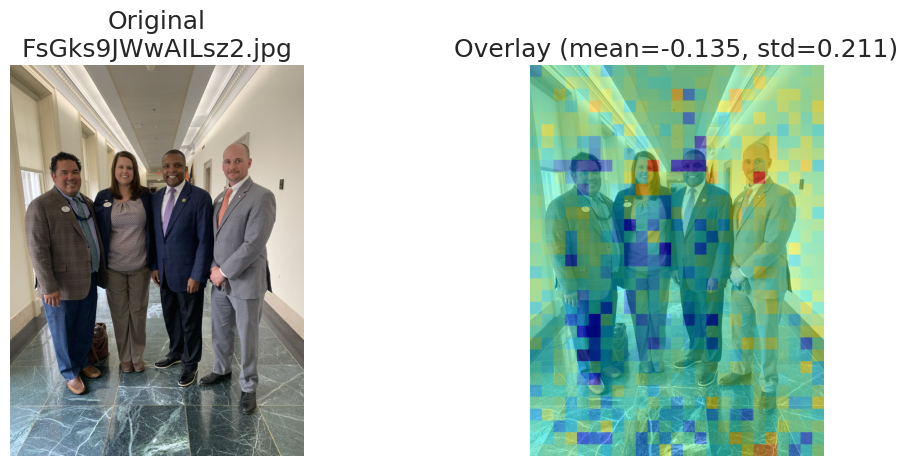

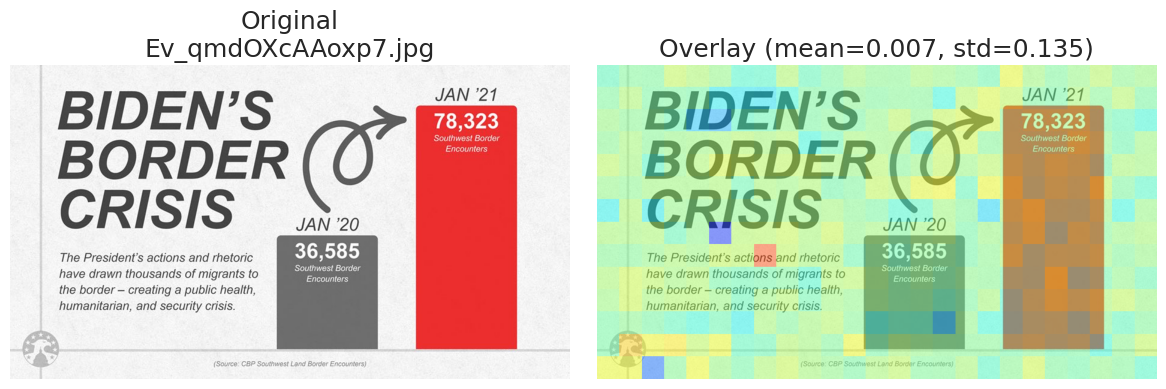

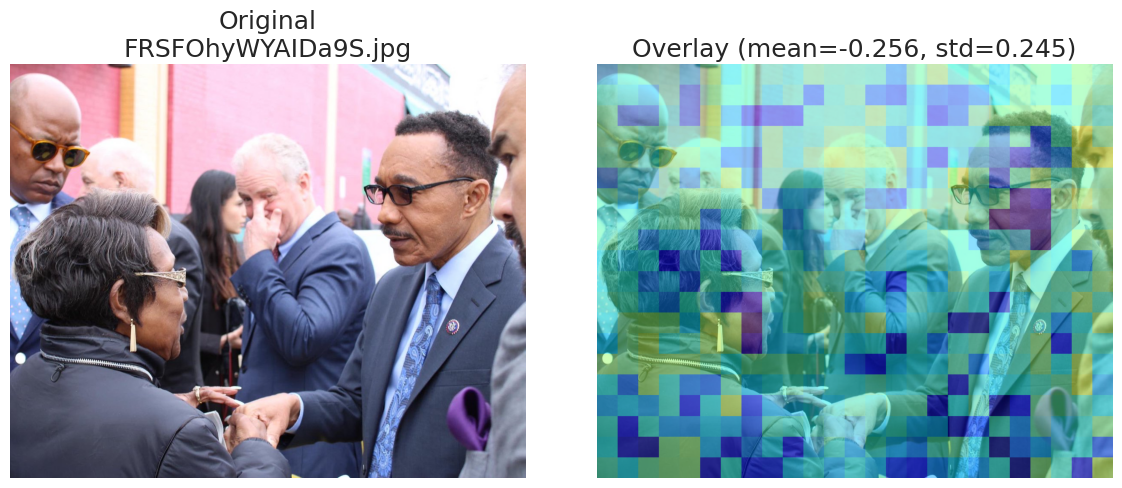

Join mode: url basename (image_name <-> url)
Matched party labels: 1367/1367


,party,n_images,mean_of_mean,median_of_mean,std_of_mean,mean_patch_std,mean_num_patches
0,Democrat,817,-0.119385,-0.117580,0.117573,0.204504,471.182375
1,Republican,547,-0.020496,-0.011519,0.112103,0.195922,476.579525


/scratch/local/jobs/48820731/ipykernel_1373846/1954997230.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_party, x="party", y="mean", palette="Set2", ax=axes[0])
/scratch/local/jobs/48820731/ipykernel_1373846/1954997230.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_party, x="party", y="mean", inner="quartile", palette="Set2", ax=axes[1])
/scratch/local/jobs/48820731/ipykernel_1373846/1954997230.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=party_summary, x="party", y="n_images", palette="Set2", ax=a

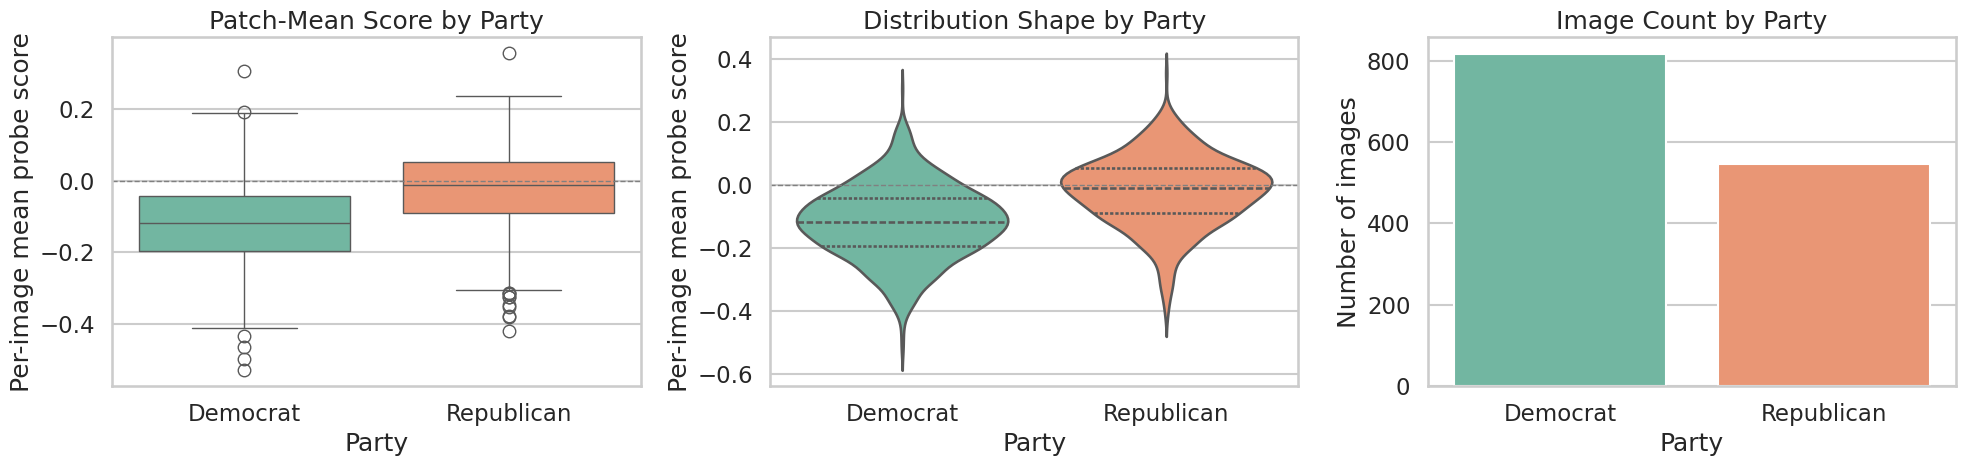

,party,q05,q25,q50,q75,q95
0,Democrat,-0.313000,-0.195229,-0.117580,-0.042150,0.072350
1,Republican,-0.208631,-0.091158,-0.011519,0.052812,0.151969


,metric,value
0,n_democrat,8.170000e+02
1,n_republican,5.470000e+02
2,mean_diff_rep_minus_dem,9.888919e-02
3,mean_diff_bootstrap_ci_low,8.632473e-02
4,mean_diff_bootstrap_ci_high,1.111855e-01
5,welch_t_stat,-1.565650e+01
6,welch_t_pvalue,1.918192e-50
7,mannwhitney_u_stat,1.174550e+05
8,mannwhitney_u_pvalue,5.460162e-50
9,cohens_d,8.568438e-01


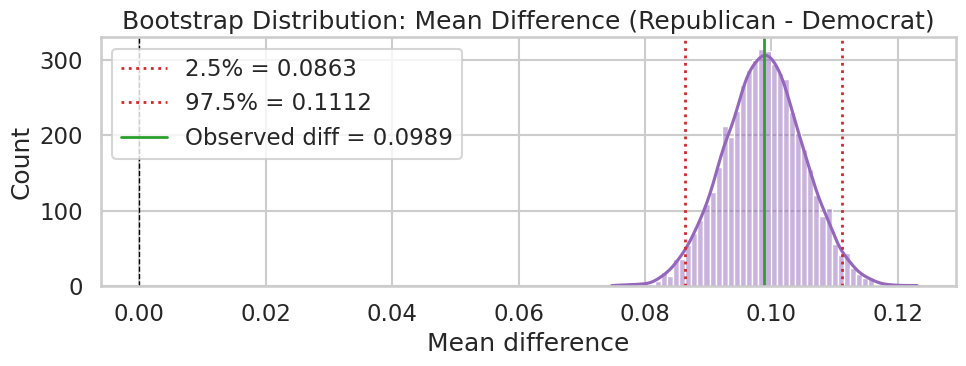

Rows with DW-NOMINATE match: 4972/5339


,metric,value
0,n_rows,4.972000e+03
1,n_unique_members,2.590000e+02
2,pearson_r,4.136497e-01
3,pearson_p,8.064686e-205
4,spearman_rho,3.957212e-01
5,spearman_p,4.523208e-186


,metric,value
0,member_level_n,2.590000e+02
1,member_level_pearson_r,5.801093e-01
2,member_level_pearson_p,1.081684e-24
3,member_level_spearman_rho,5.637235e-01
4,member_level_spearman_p,3.989388e-23


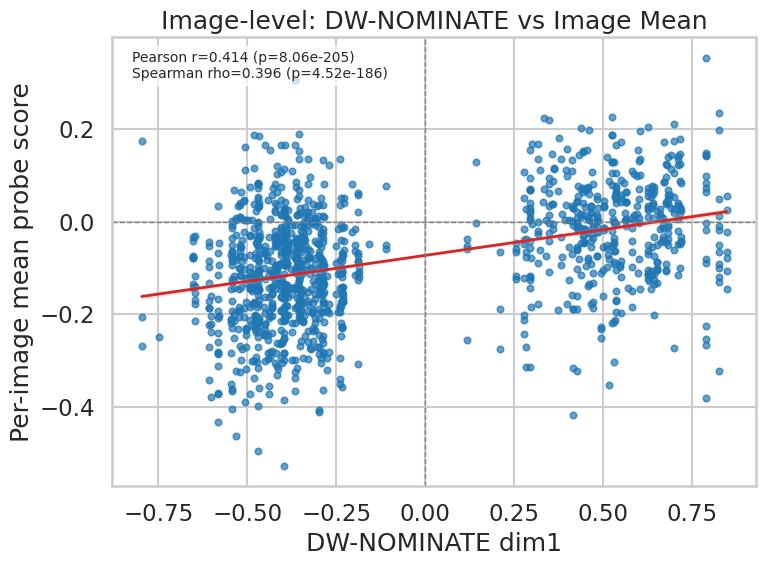

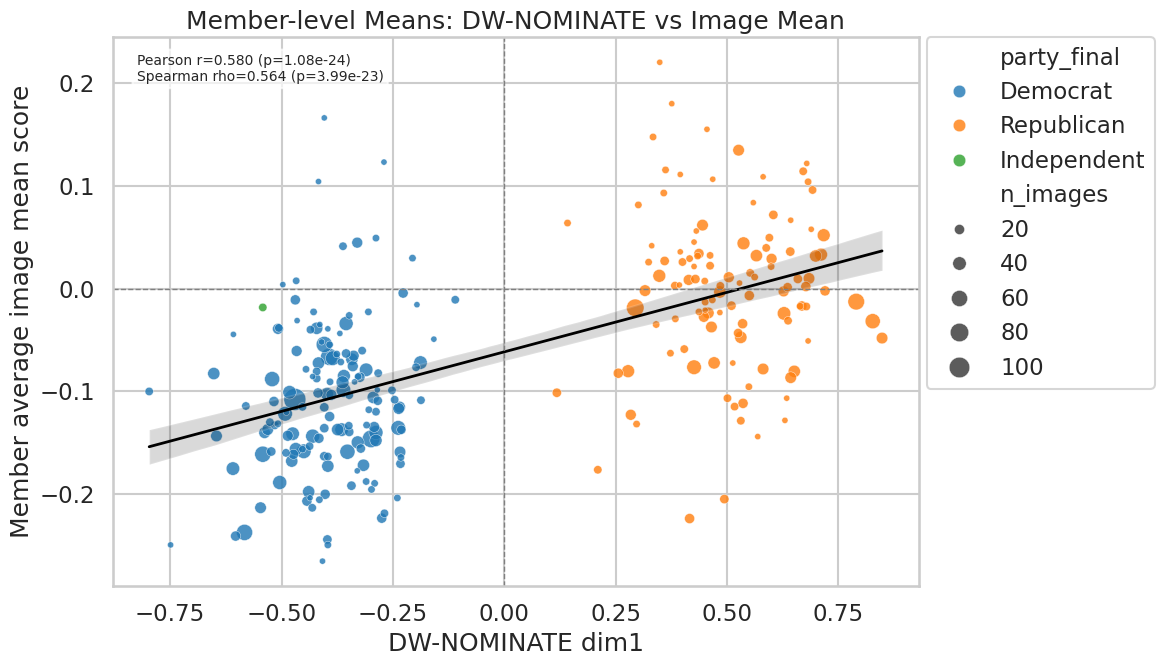

,bioguide,name,party_final,nominate_dim1,n_images,mean_image_score,std_image_score
0,E000296,Dwight Evans,Democrat,-0.470,116,-0.107946,0.147034
1,T000468,Dina Titus,Democrat,-0.299,72,-0.146323,0.125619
2,B001298,Don Bacon,Republican,0.294,72,-0.018667,0.109434
3,T000460,Mike Thompson,Democrat,-0.393,68,-0.066400,0.099046
4,C001098,Ted Cruz,Republican,0.790,64,-0.012664,0.188423
5,E000297,Adriano Espaillat,Democrat,-0.583,60,-0.237492,0.119905
6,G000585,Jimmy Gomez,Democrat,-0.542,60,-0.161291,0.123230
7,C001091,Joaquin Castro,Democrat,-0.404,60,-0.054399,0.090530
8,R000606,Jamie Raskin,Democrat,-0.521,52,-0.088103,0.110050
9,M001111,Patty Murray,Democrat,-0.352,52,-0.158861,0.069653


In [10]:
def run_all(ridge_prefix, model_name="qwen3-vl-8b-instruct", n_heatmap=6, seed=7):
    print(f"\n{'='*60}")
    print(f"  Ridge prefix: {ridge_prefix}")
    print(f"{'='*60}\n")
    payload, df_stats = load_outputs(ridge_prefix, model_name=model_name)
    show_heatmap_examples(payload, n=n_heatmap, seed=seed)
    df_party = analyze_party_comparison(df_stats)
    analyze_statistical_inference(df_party)
    analyze_dw_nominate(df_stats)


run_all("politician")



  Ridge prefix: combined_ideology

Loaded scores: results/qwen3-vl-8b-instruct/twitter_images_patch_scores_combined_ideology.pt
Loaded stats : results/qwen3-vl-8b-instruct/twitter_images_patch_stats_combined_ideology.csv
Num images   : 1367
Metadata:


model_path         /home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct
image_dir                                       data/twitter_images
ridge_prefix                                      combined_ideology
top_k                                                            16
prompt            Analyze this image. What political perspective...
max_width                                                       800
image_pad_id                                                 151655
skipped_images                                                    0
Name: value, dtype: object

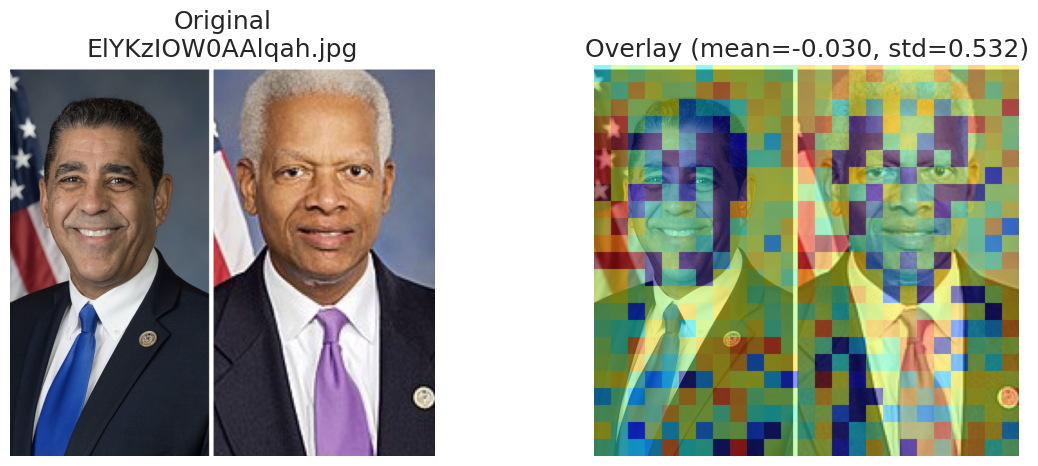

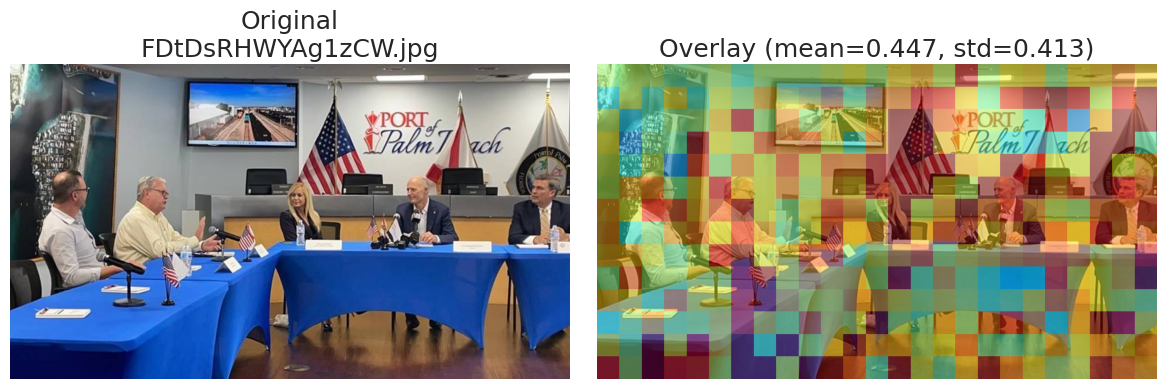

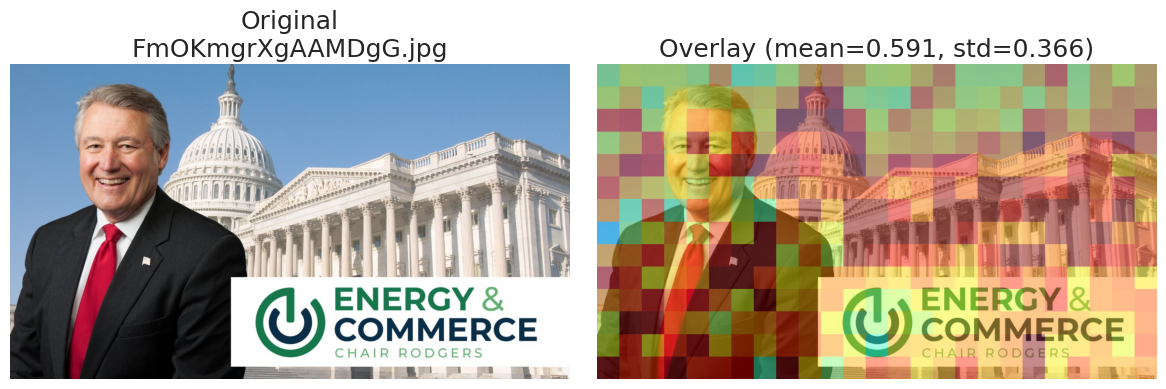

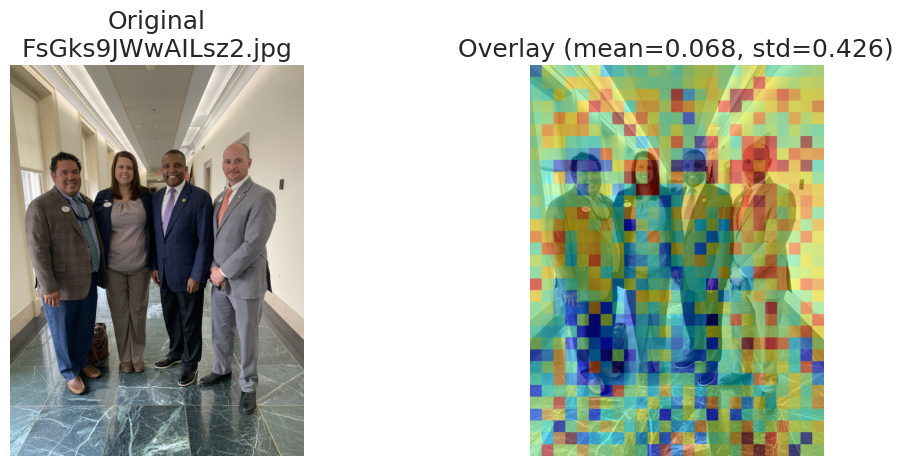

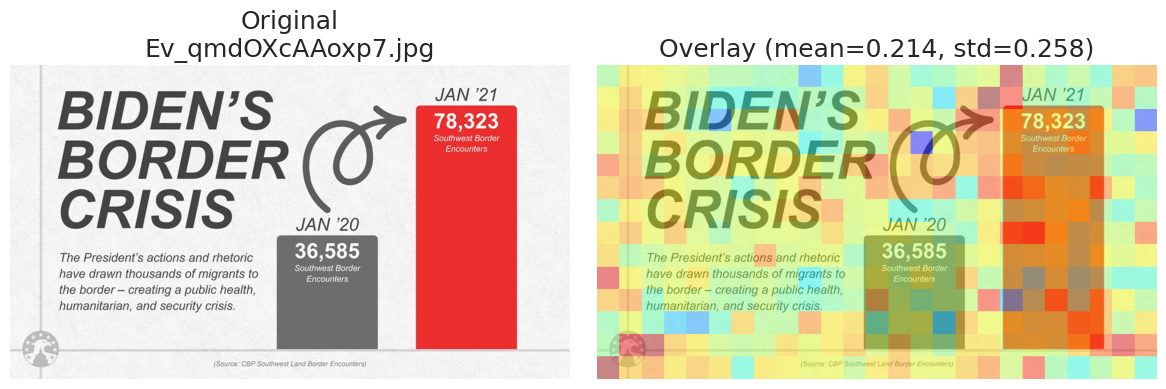

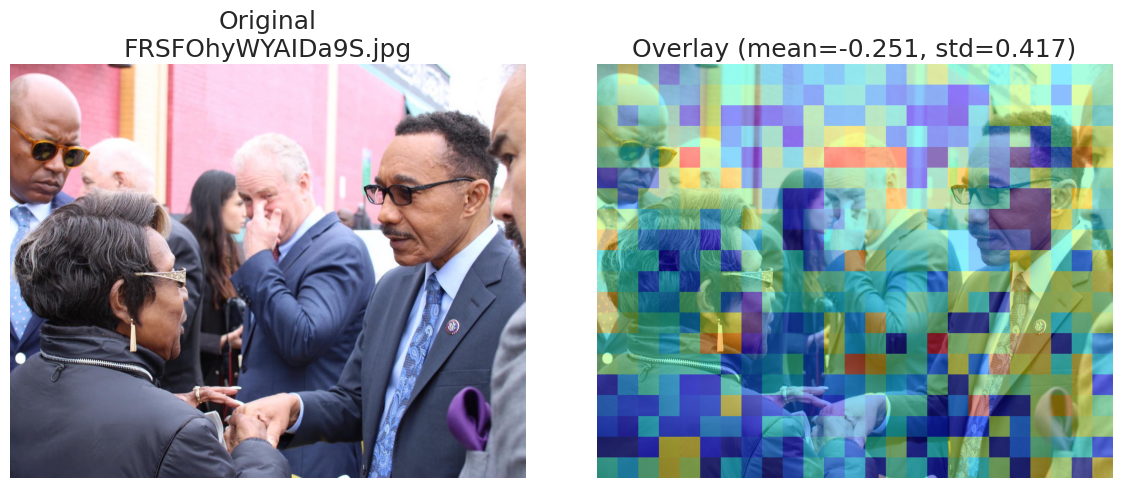

Join mode: url basename (image_name <-> url)
Matched party labels: 1367/1367


,party,n_images,mean_of_mean,median_of_mean,std_of_mean,mean_patch_std,mean_num_patches
0,Democrat,817,0.044652,0.024166,0.234469,0.375415,471.182375
1,Republican,547,0.293446,0.293574,0.240920,0.393112,476.579525


/scratch/local/jobs/48820731/ipykernel_1373846/1954997230.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_party, x="party", y="mean", palette="Set2", ax=axes[0])
/scratch/local/jobs/48820731/ipykernel_1373846/1954997230.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_party, x="party", y="mean", inner="quartile", palette="Set2", ax=axes[1])
/scratch/local/jobs/48820731/ipykernel_1373846/1954997230.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=party_summary, x="party", y="n_images", palette="Set2", ax=a

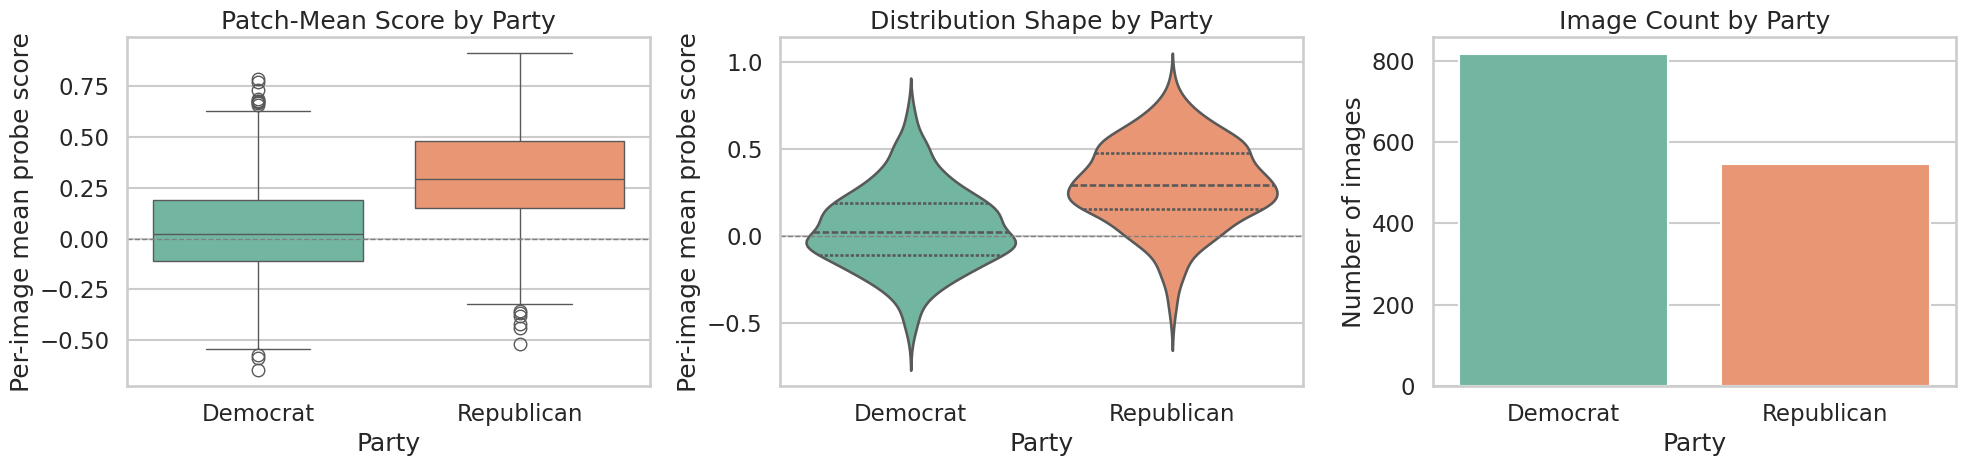

,party,q05,q25,q50,q75,q95
0,Democrat,-0.312815,-0.111126,0.024166,0.191733,0.467269
1,Republican,-0.099773,0.152202,0.293574,0.478424,0.663566


,metric,value
0,n_democrat,8.170000e+02
1,n_republican,5.470000e+02
2,mean_diff_rep_minus_dem,2.487933e-01
3,mean_diff_bootstrap_ci_low,2.234682e-01
4,mean_diff_bootstrap_ci_high,2.750797e-01
5,welch_t_stat,-1.889353e+01
6,welch_t_pvalue,1.523606e-69
7,mannwhitney_u_stat,9.984200e+04
8,mannwhitney_u_pvalue,2.492566e-67
9,cohens_d,1.049422e+00


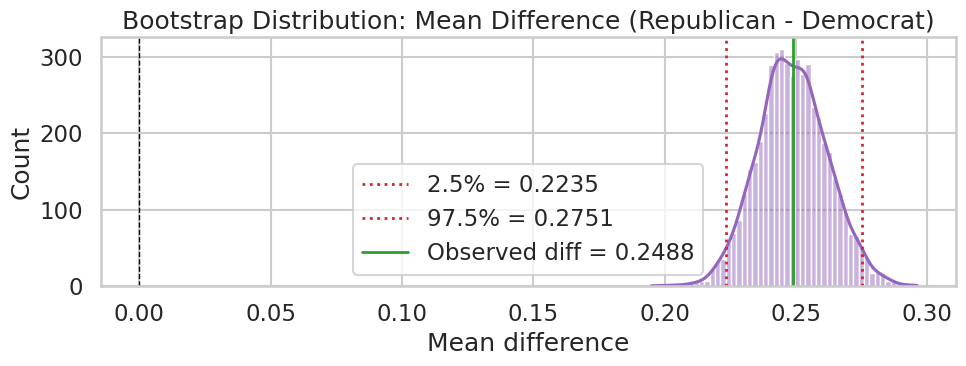

Rows with DW-NOMINATE match: 4972/5339


,metric,value
0,n_rows,4.972000e+03
1,n_unique_members,2.590000e+02
2,pearson_r,4.831464e-01
3,pearson_p,3.019622e-289
4,spearman_rho,4.555674e-01
5,spearman_p,2.245306e-253


,metric,value
0,member_level_n,2.590000e+02
1,member_level_pearson_r,6.309862e-01
2,member_level_pearson_p,3.621325e-30
3,member_level_spearman_rho,6.101297e-01
4,member_level_spearman_p,8.379334e-28


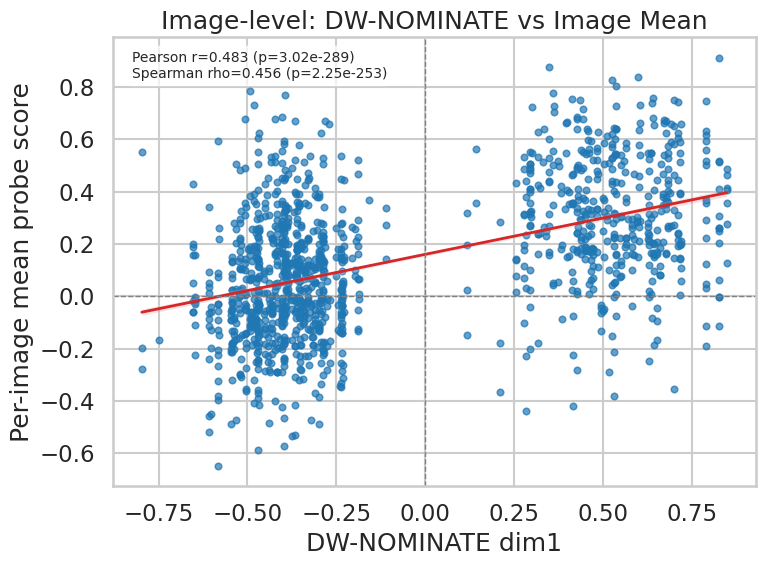

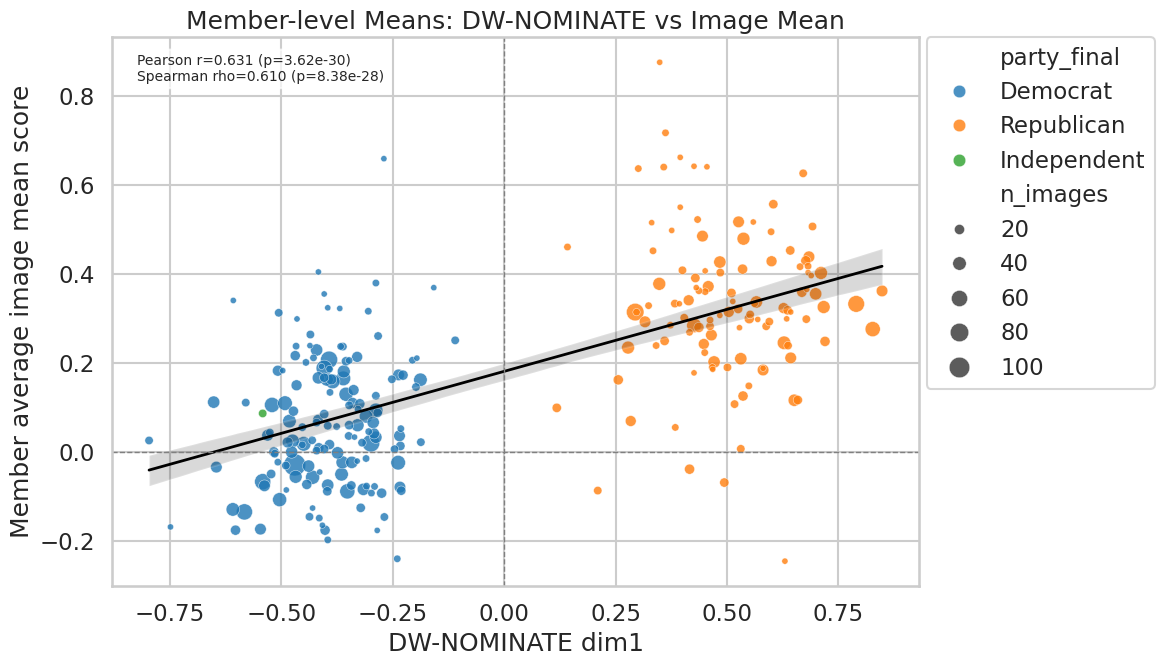

,bioguide,name,party_final,nominate_dim1,n_images,mean_image_score,std_image_score
0,E000296,Dwight Evans,Democrat,-0.470,116,-0.029680,0.286702
1,T000468,Dina Titus,Democrat,-0.299,72,0.019302,0.226473
2,B001298,Don Bacon,Republican,0.294,72,0.313856,0.208460
3,T000460,Mike Thompson,Democrat,-0.393,68,0.206920,0.210257
4,C001098,Ted Cruz,Republican,0.790,64,0.332252,0.279083
5,E000297,Adriano Espaillat,Democrat,-0.583,60,-0.135157,0.274673
6,G000585,Jimmy Gomez,Democrat,-0.542,60,-0.067262,0.126679
7,C001091,Joaquin Castro,Democrat,-0.404,60,0.187734,0.242389
8,R000606,Jamie Raskin,Democrat,-0.521,52,0.105241,0.218298
9,M001111,Patty Murray,Democrat,-0.352,52,-0.088994,0.131777


In [11]:
run_all("combined_ideology")